# **Multi-Class Classification of Malicious URLs**

# **Loading Files**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('All.csv')

# Basic Info
df.info()

# First 5 rows
print("\n--- Head of Dataset ---")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36707 entries, 0 to 36706
Data columns (total 80 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      36707 non-null  int64  
 1   domain_token_count               36707 non-null  int64  
 2   path_token_count                 36707 non-null  int64  
 3   avgdomaintokenlen                36707 non-null  float64
 4   longdomaintokenlen               36707 non-null  int64  
 5   avgpathtokenlen                  36707 non-null  float64
 6   tld                              36707 non-null  int64  
 7   charcompvowels                   36707 non-null  int64  
 8   charcompace                      36707 non-null  int64  
 9   ldl_url                          36707 non-null  int64  
 10  ldl_domain                       36707 non-null  int64  
 11  ldl_path                         36707 non-null  int64  
 12  ldl_filename      

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,0.0,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


# **Exploratory Data Analysis**

In [ ]:
df.describe()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_Directoryname,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath
count,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,...,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000
mean,21.908492,2.857439,8.954668,5.401719,9.746016,4.521506,2.857439,14.976517,10.216117,3.363909,...,1.727545,3.600049,2.685237,1.903261,0.722350,0.842443,0.521174,0.711232,0.507658,-0.208866
std,94.280609,0.906562,4.278406,1.986858,4.856580,2.856182,0.906562,13.351315,10.845807,13.447289,...,2.719231,4.783213,4.557171,4.512421,0.048820,0.066251,0.487556,0.414355,0.519682,0.891513
min,0.000000,2.000000,0.000000,1.500000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.419560,0.561913,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,2.000000,6.000000,4.000000,6.000000,3.000000,2.000000,7.000000,5.000000,0.000000,...,-1.000000,0.000000,0.000000,-1.000000,0.691929,0.795234,0.000000,0.718628,0.000000,-1.000000
50%,0.000000,3.000000,8.000000,5.000000,9.000000,4.000000,3.000000,13.000000,8.000000,0.000000,...,1.000000,1.000000,0.000000,-1.000000,0.723003,0.835752,0.750717,0.784744,0.728721,-1.000000
75%,19.000000,3.000000,11.000000,6.500000,12.000000,5.000000,3.000000,19.000000,12.000000,1.000000,...,3.000000,6.000000,4.000000,3.000000,0.754305,0.884735,0.827729,0.884311,0.907449,0.758695
max,1385.000000,19.000000,68.000000,29.500000,63.000000,105.000000,19.000000,193.000000,142.000000,207.000000,...,24.000000,40.000000,39.000000,40.000000,0.895403,1.000000,0.962479,1.000000,1.000000,1.000000


## **Missing Values Analysis**
This block checks for any null or missing entries in the dataset.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("\n--- Missing Values Count ---")
print(missing_values[missing_values > 0])

# Summary of missing values
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing values: {missing_values.sum()}")


--- Missing Values Count ---
Series([], dtype: int64)
No missing values found in the dataset.


## **Target Variable Distribution**
Visualizing the balance between classes (Benign vs. various Malicious types).

/tmp/ipython-input-3128245009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='URL_Type_obf_Type', palette='viridis', order=df['URL_Type_obf_Type'].value_counts().index)


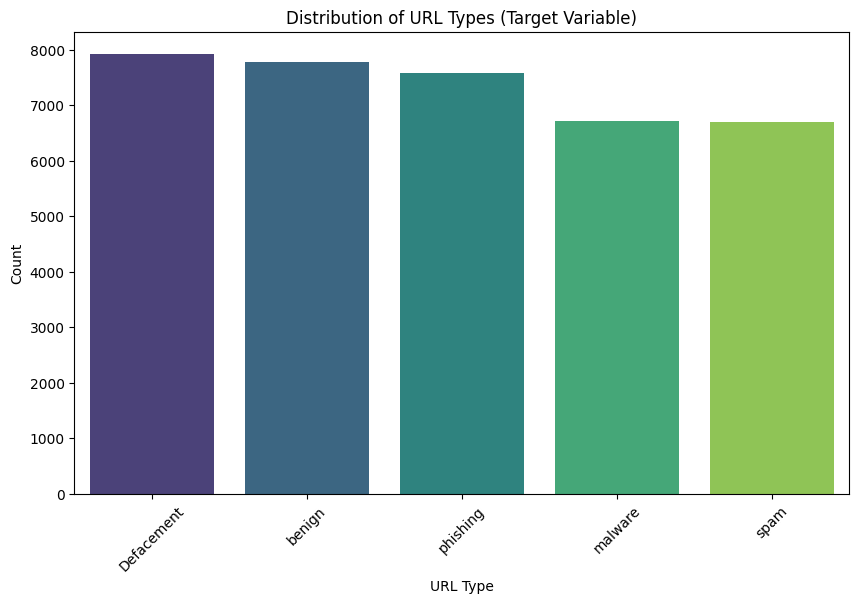

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='URL_Type_obf_Type', palette='viridis', order=df['URL_Type_obf_Type'].value_counts().index)
plt.title('Distribution of URL Types (Target Variable)')
plt.xlabel('URL Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## **Correlation Heatmap**
Since there are 80 columns, we visualize the correlation between the first 15 features to keep the heatmap readable.

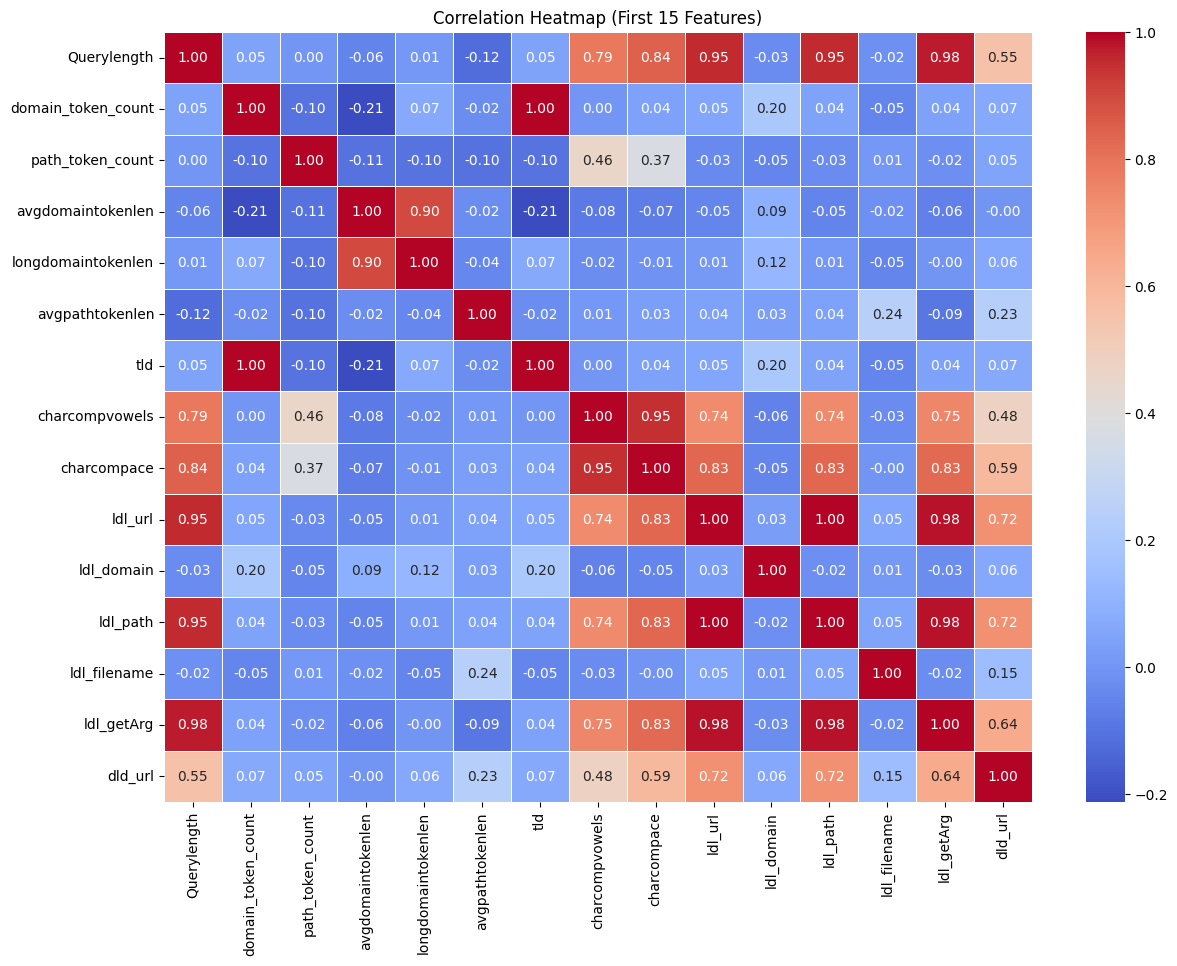

In [ ]:
plt.figure(figsize=(14, 10))
# Selecting a subset of features for better visibility
subset_corr = df.iloc[:, :15].join(df['URL_Type_obf_Type'])
corr_matrix = subset_corr.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (First 15 Features)')
plt.show()

## **Distribution Graphs**
Histograms for key features like URL length and Entropy to understand their spread.

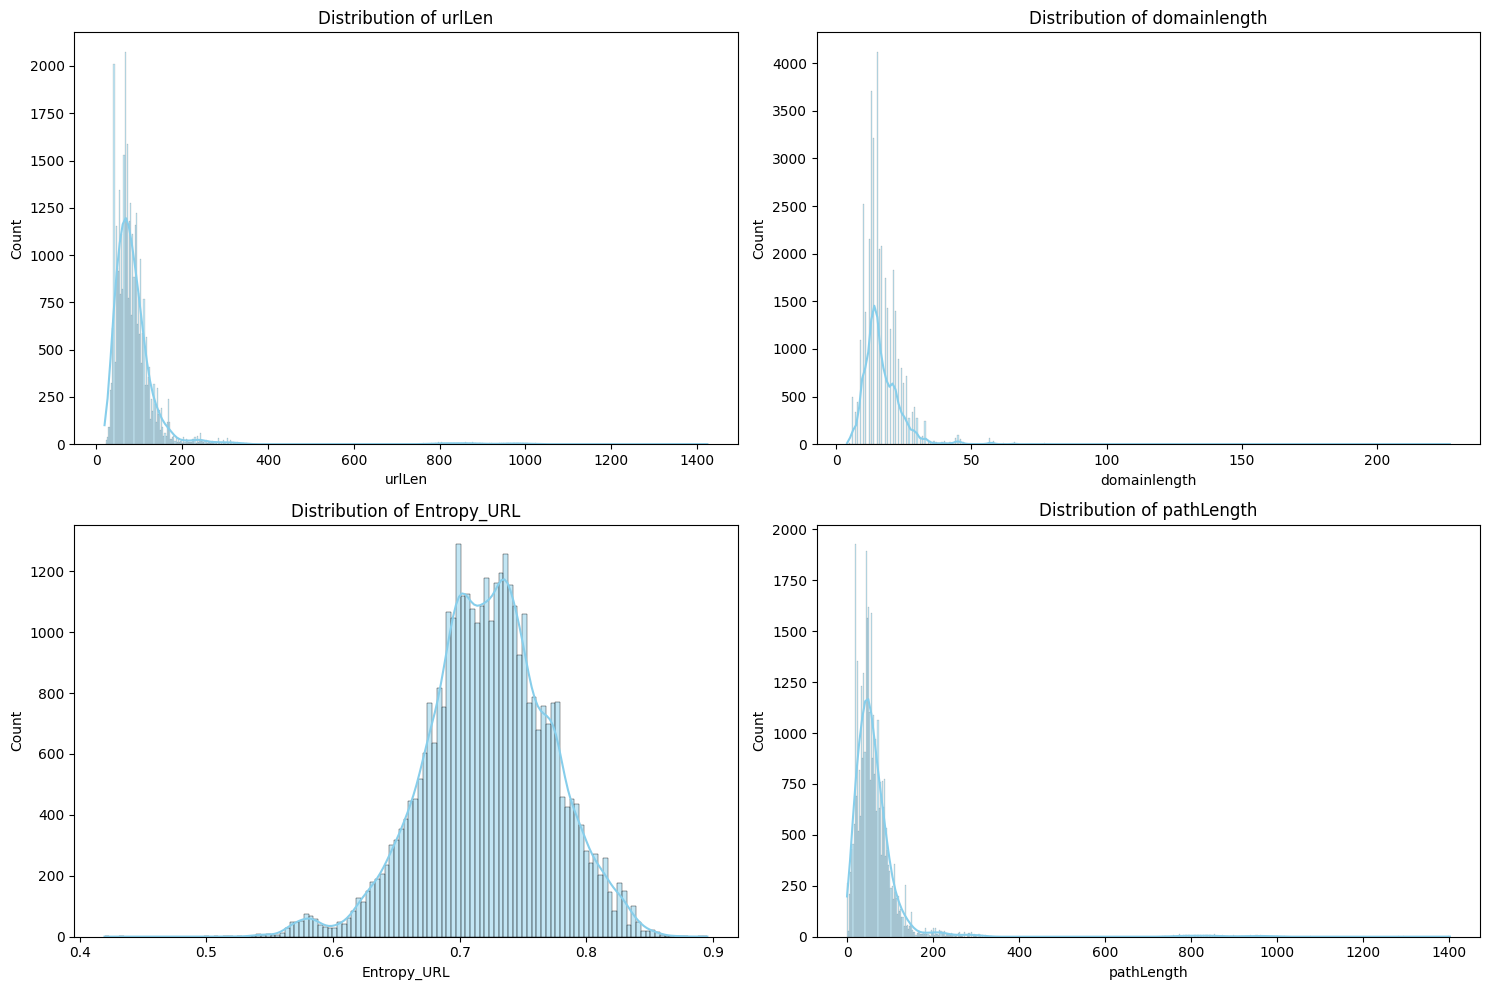

In [ ]:
features_to_plot = ['urlLen', 'domainlength', 'Entropy_URL', 'pathLength']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## **Pair Plot**
Visualizing relationships between a selected subset of features colored by the target class.

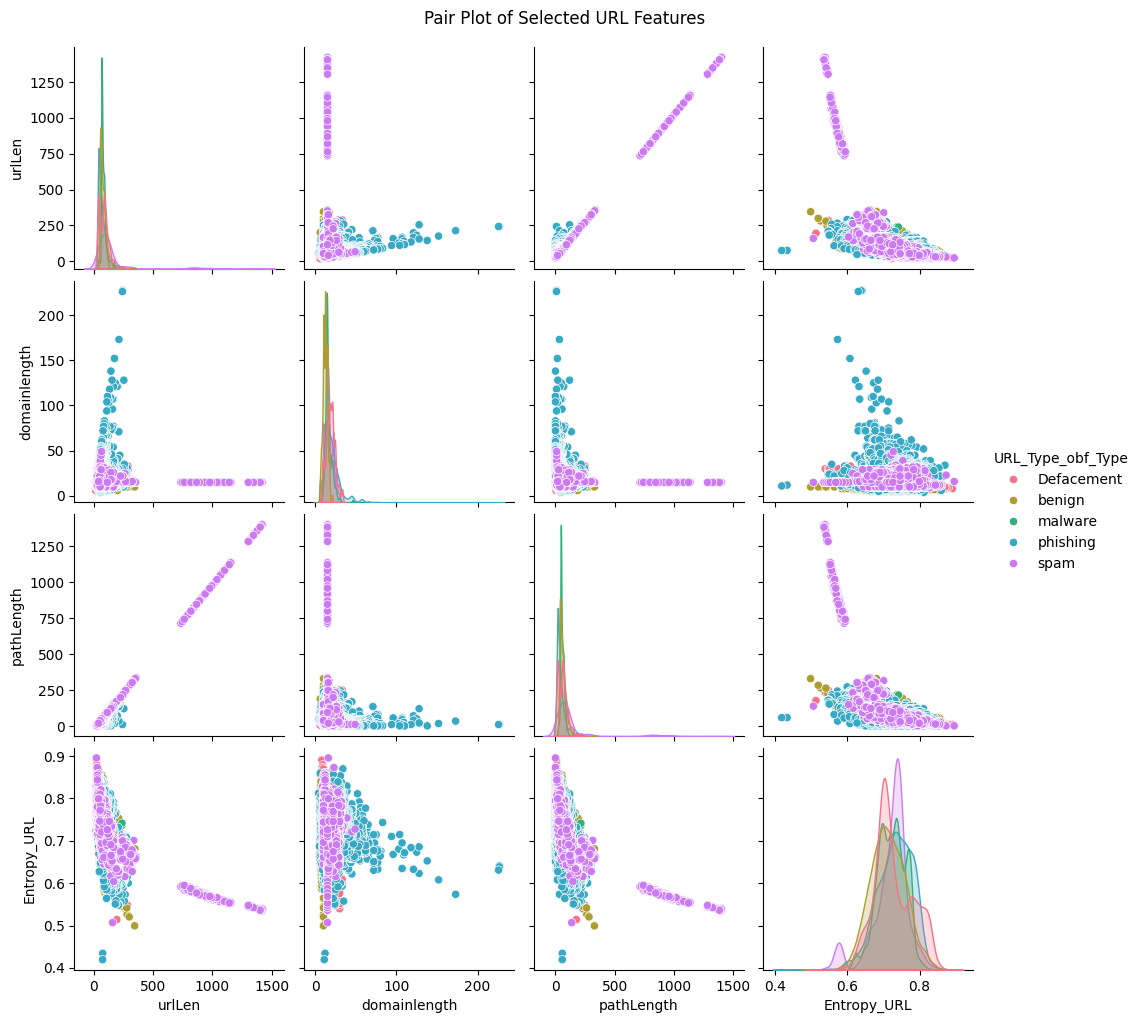

In [ ]:
# Selecting a few representative features for the pair plot
pairplot_features = ['urlLen', 'domainlength', 'pathLength', 'Entropy_URL', 'URL_Type_obf_Type']
sns.pairplot(df[pairplot_features], hue='URL_Type_obf_Type', palette='husl', diag_kind='kde')
plt.suptitle('Pair Plot of Selected URL Features', y=1.02)
plt.show()

df.head()

In [ ]:
df.head()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,0.0,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement
